In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
#seperate feature and target
#X contains all input features
X = df.drop("DEATH_EVENT", axis=1)

#y contains the target variable
y = df["DEATH_EVENT"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (299, 12)
Target shape: (299,)


In [4]:
#baseline model before feature engineering
#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train baseline Logistic Regression model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

#predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60



In [5]:
#log transformation reduce 极端值影响 --serum_creatinine 和 creatinine_phosphokinase
df_fe = df.copy()

df_fe["log_serum_creatinine"] = np.log1p(df_fe["serum_creatinine"])
df_fe["log_creatinine_phosphokinase"] = np.log1p(df_fe["creatinine_phosphokinase"])

df_fe[["serum_creatinine", "log_serum_creatinine",
       "creatinine_phosphokinase", "log_creatinine_phosphokinase"]].head()

,serum_creatinine,log_serum_creatinine,creatinine_phosphokinase,log_creatinine_phosphokinase
0,1.9,1.064711,582,6.368187
1,1.1,0.741937,7861,8.969796
2,1.3,0.832909,146,4.990433
3,1.9,1.064711,111,4.718499
4,2.7,1.308333,160,5.081404


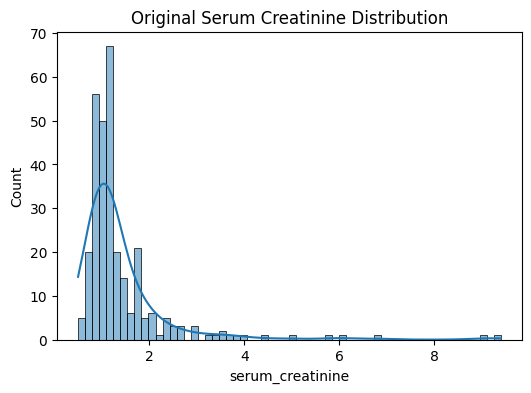

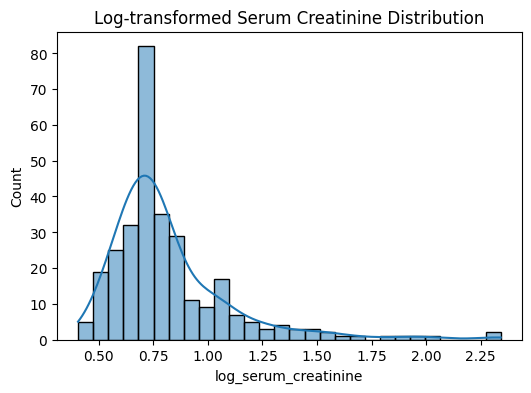

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["serum_creatinine"], kde=True)
plt.title("Original Serum Creatinine Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df_fe["log_serum_creatinine"], kde=True)
plt.title("Log-transformed Serum Creatinine Distribution")
plt.show()

图形在整理后更加接近正态分布